In [16]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torchvision import datasets, transforms
# import matplotlib.pyplot as plt

# # Define the neural network architecture
# class LocalLearningNet(nn.Module):
#     def __init__(self, input_size=784, hidden_size=256, output_size=10):
#         super(LocalLearningNet, self).__init__()
#         # Forward weights
#         self.fc1 = nn.Linear(input_size, hidden_size, bias=True)
#         self.fc2 = nn.Linear(hidden_size, output_size, bias=True)
#         # Feedback weights for local learning
#         self.fb1 = nn.Linear(output_size, hidden_size, bias=False)
#         # Activation functions
#         self.relu = nn.ReLU()
#         self.softmax = nn.Softmax(dim=1)
#         # Initialize feedback weights
#         nn.init.kaiming_normal_(self.fb1.weight)

#     def forward(self, x):
#         h1 = self.relu(self.fc1(x))
#         y_hat = self.softmax(self.fc2(h1))
#         return h1, y_hat

#     def feedback(self, y_tilde):
#         h1_tilde = self.fb1(y_tilde)
#         return h1_tilde

# # Custom optimizer implementing local learning rules
# class LocalLearningOptimizer(optim.Optimizer):
#     def __init__(self, params, lr=0.01, gamma=0.001, lamda=0.001):
#         defaults = dict(lr=lr, gamma=gamma, lamda=lamda)
#         super(LocalLearningOptimizer, self).__init__(params, defaults)

#     def step(self, closure=None):
#         for group in self.param_groups:
#             lr = group['lr']
#             gamma = group['gamma']
#             lamda = group['lamda']
#             for p in group['params']:
#                 if p.grad is None:
#                     continue
#                 # Error correction term
#                 delta = p.grad.data
#                 # Alignment term
#                 alignment_term = gamma * p.data
#                 # RQ term (simplified as weight decay)
#                 rq_term = lamda * p.data
#                 # Update weights
#                 p.data -= lr * (delta + alignment_term + rq_term)

# # Standard training function using backpropagation
# def train_backprop(model, device, train_loader, optimizer, epoch, train_losses, train_accuracies):
#     model.train()
#     correct = 0
#     total = 0
#     for data, target in train_loader:
#         data = data.view(-1, 784).to(device)
#         target = target.to(device)
#         optimizer.zero_grad()
#         # Forward pass
#         _, output = model(data)
#         # Compute loss
#         loss = nn.CrossEntropyLoss()(output, target)
#         # Backward pass
#         loss.backward()
#         # Update weights
#         optimizer.step()
#         # Accumulate training loss
#         train_losses.append(loss.item())
#         # Compute accuracy
#         pred = output.argmax(dim=1)
#         correct += pred.eq(target).sum().item()
#         total += target.size(0)
#     accuracy = 100. * correct / total
#     train_accuracies.append(accuracy)
#     print(f'Epoch {epoch}, Backpropagation Training Accuracy: {accuracy:.2f}%')

# # Training function using local learning rules
# def train_local_learning(model, device, train_loader, optimizer, epoch, train_losses, train_accuracies):
#     model.train()
#     correct = 0
#     total = 0
#     for data, target in train_loader:
#         data = data.view(-1, 784).to(device)
#         target = target.to(device)
#         # Forward pass
#         h1, y_hat = model(data)
#         # Compute local targets
#         y_tilde = torch.zeros_like(y_hat).scatter_(
#             1, target.view(-1, 1), 1.0)
#         h1_tilde = h1 + model.feedback(y_tilde) - model.feedback(y_hat)
#         # Compute local errors
#         delta2 = y_hat - y_tilde
#         delta1 = h1 - h1_tilde
#         # Zero gradients
#         optimizer.zero_grad()
#         # Compute gradients for output layer
#         model.fc2.weight.grad = torch.matmul(
#             delta2.t(), h1) / data.size(0)
#         model.fc2.bias.grad = delta2.mean(dim=0)
#         # Compute gradients for hidden layer
#         delta1_activation = delta1 * (h1 > 0).float()
#         model.fc1.weight.grad = torch.matmul(
#             delta1_activation.t(), data) / data.size(0)
#         model.fc1.bias.grad = delta1_activation.mean(dim=0)
#         # Update weights
#         optimizer.step()
#         # Accumulate training loss
#         loss = nn.MSELoss()(y_hat, y_tilde)
#         train_losses.append(loss.item())
#         # Compute accuracy
#         pred = y_hat.argmax(dim=1)
#         correct += pred.eq(target).sum().item()
#         total += target.size(0)
#     accuracy = 100. * correct / total
#     train_accuracies.append(accuracy)
#     print(f'Epoch {epoch}, Local Learning Training Accuracy: {accuracy:.2f}%')

# # Evaluation function
# def evaluate(model, device, test_loader):
#     model.eval()
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for data, target in test_loader:
#             data = data.view(-1, 784).to(device)
#             target = target.to(device)
#             _, output = model(data)
#             pred = output.argmax(dim=1)
#             correct += pred.eq(target).sum().item()
#             total += target.size(0)
#     accuracy = 100. * correct / total
#     return accuracy

# # Main function to train and compare models
# def main():
#     # Load MNIST dataset
#     transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.Normalize((0.1307,), (0.3081,))
#     ])
#     train_dataset = datasets.MNIST(
#         './data', train=True, download=True, transform=transform)
#     test_dataset = datasets.MNIST(
#         './data', train=False, download=True, transform=transform)
#     train_loader = torch.utils.data.DataLoader(
#         train_dataset, batch_size=64, shuffle=True)
#     test_loader = torch.utils.data.DataLoader(
#         test_dataset, batch_size=1000, shuffle=False)

#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#     # Initialize models
#     model_local = LocalLearningNet().to(device)
#     model_backprop = LocalLearningNet().to(device)

#     # Initialize optimizers
#     optimizer_local = LocalLearningOptimizer(
#         model_local.parameters(), lr=0.01, gamma=0.001, lamda=0.001)
#     optimizer_backprop = optim.SGD(model_backprop.parameters(), lr=0.01)

#     epochs = 10
#     # Lists to store training loss and accuracy
#     train_losses_local = []
#     train_accuracies_local = []
#     test_accuracies_local = []

#     train_losses_backprop = []
#     train_accuracies_backprop = []
#     test_accuracies_backprop = []

#     # Training with local learning rules
#     print("Training with Local Learning Rules:")
#     for epoch in range(1, epochs + 1):
#         train_local_learning(model_local, device, train_loader, optimizer_local,
#                              epoch, train_losses_local, train_accuracies_local)
#         test_accuracy = evaluate(model_local, device, test_loader)
#         test_accuracies_local.append(test_accuracy)
#         print(f'Epoch {epoch}, Local Learning Test Accuracy: {test_accuracy:.2f}%\n')

#     # Training with backpropagation
#     print("Training with Backpropagation:")
#     for epoch in range(1, epochs + 1):
#         train_backprop(model_backprop, device, train_loader, optimizer_backprop,
#                        epoch, train_losses_backprop, train_accuracies_backprop)
#         test_accuracy = evaluate(model_backprop, device, test_loader)
#         test_accuracies_backprop.append(test_accuracy)
#         print(f'Epoch {epoch}, Backpropagation Test Accuracy: {test_accuracy:.2f}%\n')

#     # Plot accuracy vs. epochs
#     epochs_range = range(1, epochs + 1)
#     plt.figure(figsize=(10, 6))
#     plt.plot(epochs_range, test_accuracies_local, label='Local Learning')
#     plt.plot(epochs_range, test_accuracies_backprop, label='Backpropagation')
#     plt.xlabel('Epoch')
#     plt.ylabel('Test Accuracy (%)')
#     plt.title('Test Accuracy vs. Epoch')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

# if __name__ == '__main__':
#     main()

In [17]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
%matplotlib inline
import torch.nn.functional as F

def one_hot_encode(labels, num_classes):
    return F.one_hot(labels, num_classes=num_classes).float()


# Define the neural network architecture
class LocalLearningNet(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, output_size=10):
        super(LocalLearningNet, self).__init__()
        # Forward weights
        self.fc1 = nn.Linear(input_size, hidden_size, bias=True)
        self.fc2 = nn.Linear(hidden_size, output_size, bias=True)
        # Feedback weights for local learning
        self.fb1 = nn.Linear(output_size, hidden_size, bias=False)
        # Activation functions
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        # Initialize feedback weights
        nn.init.kaiming_normal_(self.fb1.weight)

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        y_hat = self.softmax(self.fc2(h1))
        return h1, y_hat

    def feedback(self, y_tilde):
        h1_tilde = self.fb1(y_tilde)
        return h1_tilde
    
class LocalLearningNetWithLabels(nn.Module):
    def __init__(self, input_size=784, num_classes=10, hidden_size=256, output_size=10):
        super(LocalLearningNetWithLabels, self).__init__()
        self.input_size = input_size + num_classes  # Adjusted input size
        self.fc1 = nn.Linear(self.input_size, hidden_size, bias=True)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size, bias=True)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        y_hat = self.softmax(self.fc2(h1))
        return h1, y_hat

In [18]:
# Evaluation function to compute accuracy on the test set
def evaluate(model, device, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data = data.view(-1, 784).to(device)
            target = target.to(device)
            _, output = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
    accuracy = 100. * correct / total
    return accuracy


def evaluate_contrastive_rq_with_labels(model, device, test_loader):
    model.eval()
    correct = 0
    total = 0
    num_classes = 10
    with torch.no_grad():
        for data, target in test_loader:
            data = data.view(-1, 784).to(device)
            target = target.to(device)
            batch_size = data.size(0)
            one_hot_labels = one_hot_encode(target, num_classes).to(device)
            combined_input = torch.cat([data, one_hot_labels], dim=1)
            _, output = model(combined_input)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += batch_size
    accuracy = 100. * correct / total
    return accuracy

In [19]:
# Standard training function using backpropagation
def train_backprop(model, device, train_loader, optimizer, epoch, train_losses, train_accuracies):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0
    for data, target in train_loader:
        data = data.view(-1, 784).to(device)
        target = target.to(device)
        optimizer.zero_grad()
        # Forward pass
        _, output = model(data)
        # Compute loss
        loss = nn.CrossEntropyLoss()(output, target)
        epoch_loss += loss.item() * data.size(0)
        # Backward pass
        loss.backward()
        # Update weights
        optimizer.step()
        # Compute accuracy
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
    average_loss = epoch_loss / total
    accuracy = 100. * correct / total
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)
    print(f'Epoch {epoch}, Backpropagation Training Accuracy: {accuracy:.2f}%, Loss: {average_loss:.4f}')

In [20]:
# Training function using local learning rules
def train_local_learning(model, device, train_loader, optimizer, epoch, train_losses, train_accuracies):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0
    for data, target in train_loader:
        data = data.view(-1, 784).to(device)
        target = target.to(device)
        # Forward pass
        h1, y_hat = model(data)
        # Compute local targets
        y_tilde = torch.zeros_like(y_hat).scatter_(1, target.view(-1, 1), 1.0)
        h1_tilde = h1 + model.feedback(y_tilde) - model.feedback(y_hat)
        # Compute local errors
        delta2 = y_hat - y_tilde
        delta1 = h1 - h1_tilde
        # Zero gradients
        optimizer.zero_grad()
        # Compute gradients for output layer
        model.fc2.weight.grad = torch.matmul(delta2.t(), h1) / data.size(0)
        model.fc2.bias.grad = delta2.mean(dim=0)
        # Compute gradients for hidden layer
        delta1_activation = delta1 * (h1 > 0).float()
        model.fc1.weight.grad = torch.matmul(delta1_activation.t(), data) / data.size(0)
        model.fc1.bias.grad = delta1_activation.mean(dim=0)
        # Update weights
        optimizer.step()
        # Accumulate training loss
        loss = nn.MSELoss()(y_hat, y_tilde)
        epoch_loss += loss.item() * data.size(0)
        # Compute accuracy
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
    average_loss = epoch_loss / total
    accuracy = 100. * correct / total
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)
    print(f'Epoch {epoch}, Local Learning Training Accuracy: {accuracy:.2f}%, Loss: {average_loss:.4f}')

In [21]:
# Hebbian learning training function
def train_hebbian_learning(model, device, train_loader, optimizer, epoch, train_losses, train_accuracies):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0
    for data, target in train_loader:
        data = data.view(-1, 784).to(device)
        target = target.to(device)
        # Forward pass
        h1, y_hat = model(data)
        # Hebbian updates
        optimizer.zero_grad()
        # Update fc1 weights
        delta_w_fc1 = torch.matmul(h1.t(), data) / data.size(0)
        delta_b_fc1 = h1.mean(dim=0)
        model.fc1.weight.grad = delta_w_fc1
        model.fc1.bias.grad = delta_b_fc1
        # Update fc2 weights
        delta_w_fc2 = torch.matmul(y_hat.t(), h1) / data.size(0)
        delta_b_fc2 = y_hat.mean(dim=0)
        model.fc2.weight.grad = delta_w_fc2
        model.fc2.bias.grad = delta_b_fc2
        # Update weights
        optimizer.step()
        # Compute loss (for monitoring)
        loss = nn.CrossEntropyLoss()(y_hat, target)
        epoch_loss += loss.item() * data.size(0)
        # Compute accuracy
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
    average_loss = epoch_loss / total
    accuracy = 100. * correct / total
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)
    print(f'Epoch {epoch}, Hebbian Learning Training Accuracy: {accuracy:.2f}%, Loss: {average_loss:.4f}')

In [22]:
def train_rq_hebbian_learning(
    model,
    device,
    train_loader,
    optimizer_hidden,
    optimizer_output,
    epoch,
    train_losses,
    train_accuracies,
    lambda_reg=0.01
):
    model.train()
    total = 0
    epoch_loss = 0
    correct = 0
    for data, target in train_loader:
        data = data.view(-1, 784).to(device)  # [batch_size, input_size]
        target = target.to(device)
        batch_size = data.size(0)

        # Compute input covariance matrix C
        C = torch.matmul(data.t(), data) / batch_size  # Shape: [input_size, input_size]

        # Get hidden layer weights
        w = model.fc1.weight.data  # Shape: [hidden_size, input_size]

        # Compute numerator: w C
        numerator = torch.matmul(w, C)  # Shape: [hidden_size, input_size]

        # Compute denominator: w w^T
        denominator = torch.sum(w * w, dim=1, keepdim=True)  # Shape: [hidden_size, 1]

        # Compute RQ gradient
        rq_grad = numerator / (denominator + 1e-8) - lambda_reg * w  # Shape: [hidden_size, input_size]

        # Update hidden layer weights
        optimizer_hidden.zero_grad()
        model.fc1.weight.grad = rq_grad
        model.fc1.bias.grad = torch.zeros_like(model.fc1.bias)
        optimizer_hidden.step()

        # Normalize weights
        w_norm = torch.norm(model.fc1.weight.data, dim=1, keepdim=True) + 1e-8
        model.fc1.weight.data = model.fc1.weight.data / w_norm

        # Update output layer using standard backpropagation
        optimizer_output.zero_grad()
        # Forward pass after updating hidden layer
        h1, y_hat = model(data)
        loss = nn.CrossEntropyLoss()(y_hat, target)
        loss.backward()
        optimizer_output.step()

        # Accumulate loss and accuracy
        epoch_loss += loss.item() * batch_size
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += batch_size

    average_loss = epoch_loss / total
    accuracy = 100.0 * correct / total
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)
    print(f'Epoch {epoch}, RQ-based Hebbian Learning Training Accuracy: {accuracy:.2f}%, Loss: {average_loss:.4f}')

In [23]:
def train_contrastive_rq_learning(
    model,
    device,
    train_loader,
    optimizer_hidden,
    optimizer_output,
    epoch,
    train_losses,
    train_accuracies,
    lambda_reg=0.01
):
    model.train()
    total = 0
    epoch_loss = 0
    correct = 0
    num_classes = 10  # Number of classes in MNIST

    for data, target in train_loader:
        data = data.view(-1, 784).to(device)  # [batch_size, input_size]
        target = target.to(device)
        batch_size = data.size(0)

        # Positive phase: Original data
        h1_pos, _ = model(data)

        # # Negative phase: Noisy data
        # noise = torch.randn_like(data) * 0.1
        # data_noisy = data + noise
        # h1_neg, _ = model(data_noisy)
        # Negative phase: Shuffle labels
        
        # Negative phase: Shuffle labels
        shuffled_target = target[torch.randperm(batch_size)]
        one_hot_shuffled_labels = one_hot_encode(shuffled_target, num_classes).to(device)
        combined_input_neg = torch.cat([data, one_hot_shuffled_labels], dim=1)
        h_neg, _ = model(combined_input_neg)
        
        # Compute difference in activations
        delta_h1 = h1_pos - h1_neg  # [batch_size, hidden_size]

        # Compute covariance matrix C
        C = torch.matmul(delta_h1.t(), data) / batch_size  # [hidden_size, input_size]

        # Get hidden layer weights
        w = model.fc1.weight.data  # [hidden_size, input_size]

        # Compute numerator and denominator
        numerator = C  # [hidden_size, input_size]
        denominator = torch.sum(w * w, dim=1, keepdim=True)  # [hidden_size, 1]

        # Compute RQ gradient
        rq_grad = numerator / (denominator + 1e-8) - lambda_reg * w  # [hidden_size, input_size]

        # Update hidden layer weights
        optimizer_hidden.zero_grad()
        model.fc1.weight.grad = rq_grad
        model.fc1.bias.grad = torch.zeros_like(model.fc1.bias)
        optimizer_hidden.step()

        # Normalize weights
        w_norm = torch.norm(model.fc1.weight.data, dim=1, keepdim=True) + 1e-8
        model.fc1.weight.data = model.fc1.weight.data / w_norm

        # Update output layer using standard backpropagation
        optimizer_output.zero_grad()
        # Forward pass after updating hidden layer
        h1, y_hat = model(data)
        loss = nn.CrossEntropyLoss()(y_hat, target)
        loss.backward()
        optimizer_output.step()

        # Accumulate loss and accuracy
        epoch_loss += loss.item() * batch_size
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += batch_size

    average_loss = epoch_loss / total
    accuracy = 100.0 * correct / total
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)
    print(f'Epoch {epoch}, Contrastive RQ Learning Training Accuracy: {accuracy:.2f}%, Loss: {average_loss:.4f}')
    
    
    
def train_contrastive_rq_with_labels(model, device, train_loader, optimizer_hidden, optimizer_output, epoch, train_losses, train_accuracies, lambda_reg=0.01):
    model.train()
    total = 0
    epoch_loss = 0
    correct = 0
    num_classes = 10  # Number of classes in MNIST
    for data, target in train_loader:
        data = data.view(-1, 784).to(device)  # [batch_size, 784]
        target = target.to(device)  # [batch_size]
        batch_size = data.size(0)

        # One-hot encode the labels
        one_hot_labels = one_hot_encode(target, num_classes).to(device)  # [batch_size, 10]

        # Concatenate data and labels
        combined_input = torch.cat([data, one_hot_labels], dim=1)  # [batch_size, 794]

        # Positive phase
        h_pos, _ = model(combined_input)

        # Negative phase: Shuffle labels
        shuffled_target = target[torch.randperm(batch_size)]
        one_hot_shuffled_labels = one_hot_encode(shuffled_target, num_classes).to(device)
        combined_input_neg = torch.cat([data, one_hot_shuffled_labels], dim=1)

        h_neg, _ = model(combined_input_neg)

        # Compute difference in activations
        delta_h = h_pos - h_neg  # [batch_size, hidden_size]

        # Compute covariance matrix C
        C = torch.matmul(delta_h.t(), combined_input) / batch_size  # [hidden_size, 794]

        # Get weights
        w = model.fc1.weight.data  # [hidden_size, 794]

        # Compute numerator and denominator
        numerator = C  # [hidden_size, 794]
        denominator = torch.sum(w * w, dim=1, keepdim=True)  # [hidden_size, 1]

        # Compute RQ gradient
        rq_grad = numerator / (denominator + 1e-8) - lambda_reg * w

        # Update hidden layer weights
        optimizer_hidden.zero_grad()
        model.fc1.weight.grad = rq_grad
        model.fc1.bias.grad = torch.zeros_like(model.fc1.bias)
        optimizer_hidden.step()

        # Normalize weights
        w_norm = torch.norm(model.fc1.weight.data, dim=1, keepdim=True) + 1e-8
        model.fc1.weight.data = model.fc1.weight.data / w_norm

        # Update output layer using standard backpropagation
        optimizer_output.zero_grad()
        # Forward pass after updating hidden layer
        h1, y_hat = model(combined_input)
        loss = nn.CrossEntropyLoss()(y_hat, target)
        loss.backward()
        optimizer_output.step()

        # Accumulate loss and accuracy
        epoch_loss += loss.item() * batch_size
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += batch_size

    average_loss = epoch_loss / total
    accuracy = 100.0 * correct / total
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)
    print(f'Epoch {epoch}, Contrastive RQ Learning with Shuffled Labels Training Accuracy: {accuracy:.2f}%, Loss: {average_loss:.4f}')
    
def evaluate_contrastive_rq_with_labels(model, device, test_loader):
    model.eval()
    correct = 0
    total = 0
    num_classes = 10
    with torch.no_grad():
        for data, target in test_loader:
            data = data.view(-1, 784).to(device)
            target = target.to(device)
            batch_size = data.size(0)
            one_hot_labels = one_hot_encode(target, num_classes).to(device)
            combined_input = torch.cat([data, one_hot_labels], dim=1)
            _, output = model(combined_input)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += batch_size
    accuracy = 100. * correct / total
    return accuracy

In [24]:
def train_competitive_rq_learning(
    model,
    device,
    train_loader,
    optimizer_hidden,
    optimizer_output,
    epoch,
    train_losses,
    train_accuracies,
    lambda_reg=0.01
):
    model.train()
    total = 0
    epoch_loss = 0
    correct = 0
    for data, target in train_loader:
        data = data.view(-1, 784).to(device)  # [batch_size, input_size]
        target = target.to(device)
        batch_size = data.size(0)

        # Compute input covariance matrix C
        C = torch.matmul(data.t(), data) / batch_size  # Shape: [input_size, input_size]

        # Get hidden layer weights
        w = model.fc1.weight.data  # Shape: [hidden_size, input_size]

        # Compute numerator: w C
        numerator = torch.matmul(w, C)  # Shape: [hidden_size, input_size]

        # Compute denominator: w w^T
        denominator = torch.sum(w * w, dim=1, keepdim=True)  # Shape: [hidden_size, 1]

        # Compute RQ gradient
        rq_grad = numerator / (denominator + 1e-8) - lambda_reg * w  # Shape: [hidden_size, input_size]

        # Competition term
        norms = torch.norm(w, dim=1, keepdim=True)  # [hidden_size, 1]
        dot_products = torch.matmul(w, w.t())  # [hidden_size, hidden_size]
        norm_products = norms @ norms.t() + 1e-8  # [hidden_size, hidden_size]
        overlaps = dot_products / norm_products  # [hidden_size, hidden_size]
        overlaps.fill_diagonal_(0)
        competition = -torch.matmul(overlaps, w)  # [hidden_size, input_size]

        # Total gradient
        total_grad = rq_grad + competition  # [hidden_size, input_size]

        # Update hidden layer weights
        optimizer_hidden.zero_grad()
        model.fc1.weight.grad = total_grad
        model.fc1.bias.grad = torch.zeros_like(model.fc1.bias)
        optimizer_hidden.step()

        # Normalize weights
        w_norm = torch.norm(model.fc1.weight.data, dim=1, keepdim=True) + 1e-8
        model.fc1.weight.data = model.fc1.weight.data / w_norm

        # Update output layer using standard backpropagation
        optimizer_output.zero_grad()
        # Forward pass after updating hidden layer
        h1, y_hat = model(data)
        loss = nn.CrossEntropyLoss()(y_hat, target)
        loss.backward()
        optimizer_output.step()

        # Accumulate loss and accuracy
        epoch_loss += loss.item() * batch_size
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += batch_size

    average_loss = epoch_loss / total
    accuracy = 100.0 * correct / total
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)
    print(f'Epoch {epoch}, Competitive RQ Learning Training Accuracy: {accuracy:.2f}%, Loss: {average_loss:.4f}')

In [25]:
def train_class_conditioned_rq_learning(model, device, train_loader, optimizer_hidden, optimizer_output, epoch, train_losses, train_accuracies, lambda_reg=1):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0
    for data, target in train_loader:
        data = data.view(-1, 784).to(device)
        target = target.to(device)
        batch_size = data.size(0)
        # Forward pass
        h1, y_hat = model(data)
        # Compute class-conditioned covariance matrices
        classes = target.unique()
        Cc = {}
        for c in classes:
            mask = (target == c)
            data_c = data[mask]
            N_c = data_c.size(0)
            if N_c > 1:
                mu_c = data_c.mean(dim=0, keepdim=True)
                X_c = data_c - mu_c
                Cc[int(c.item())] = (X_c.t() @ X_c) / N_c
            else:
                Cc[int(c.item())] = torch.zeros((784, 784)).to(device)
        # Compute gradient for hidden layer weights
        w = model.fc1.weight.data  # Shape: [hidden_size, input_size]
        numerator = torch.zeros_like(w)
        denominator = torch.sum(w * w, dim=1, keepdim=True)
        for i in range(batch_size):
            xi = data[i]  # Shape: [input_size]
            yi = target[i].item()
            # Numerator: Cc[yi] @ w
            Ci_w = Cc[yi] @ w.t()  # Shape: [784, hidden_size]
            numerator += Ci_w.t()
        numerator /= batch_size
        # Compute gradient
        rq_grad = numerator / (denominator + 1e-8) - lambda_reg * w
        # Update hidden layer weights
        optimizer_hidden.zero_grad()
        model.fc1.weight.grad = rq_grad
        model.fc1.bias.grad = torch.zeros_like(model.fc1.bias)
        optimizer_hidden.step()
        # Normalize weights
        w_norm = torch.norm(model.fc1.weight.data, dim=1, keepdim=True) + 1e-8
        model.fc1.weight.data = model.fc1.weight.data / w_norm
        # Update output layer using standard backpropagation
        optimizer_output.zero_grad()
        # Forward pass after updating hidden layer
        h1, y_hat = model(data)
        loss = nn.CrossEntropyLoss()(y_hat, target)
        loss.backward()
        optimizer_output.step()
        epoch_loss += loss.item() * batch_size
        # Compute accuracy
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += batch_size
    average_loss = epoch_loss / total
    accuracy = 100. * correct / total
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)
    print(f'Epoch {epoch}, Class-Conditioned RQ Learning Training Accuracy: {accuracy:.2f}%, Loss: {average_loss:.4f}')

In [26]:
def train_rq_maximization(model, device, train_loader, optimizer_hidden, optimizer_output, epoch, train_losses, train_accuracies, lambda_reg=1):
    model.train()
    total = 0
    epoch_loss = 0
    correct = 0
    for data, target in train_loader:
        data = data.view(-1, 784).to(device)
        target = target.to(device)
        batch_size = data.size(0)
        # Compute projections: x_i^T w
        w = model.fc1.weight.data  # Shape: [hidden_size, input_size]
        D = torch.sum(w * w, dim=1, keepdim=True)  # Shape: [hidden_size, 1]
        xw = torch.matmul(data, w.t())  # Shape: [batch_size, hidden_size]
        # Compute C w
        Cw = torch.matmul(data.t(), xw) / batch_size  # Shape: [input_size, hidden_size]
        Cw = Cw.t()  # Shape: [hidden_size, input_size]
        # Compute w^T C w
        w_C_w = torch.sum(xw ** 2, dim=0, keepdim=True).t() / batch_size  # Shape: [hidden_size, 1]
        # Compute gradient
        numerator = (Cw * D) - (w * w_C_w)
        denominator = D ** 2 + 1e-8  # Add small epsilon to prevent division by zero
        grad_w = -2 * numerator / denominator + 2 * lambda_reg * w
        # Update hidden layer weights
        optimizer_hidden.zero_grad()
        model.fc1.weight.grad = grad_w
        model.fc1.bias.grad = torch.zeros_like(model.fc1.bias)
        optimizer_hidden.step()
        # Normalize weights
        w_norm = torch.norm(model.fc1.weight.data, dim=1, keepdim=True) + 1e-8
        model.fc1.weight.data = model.fc1.weight.data / w_norm
        total += batch_size
        # Update output layer using standard backpropagation
        optimizer_output.zero_grad()
        # Forward pass after updating hidden layer
        h1, y_hat = model(data)
        loss = nn.CrossEntropyLoss()(y_hat, target)
        loss.backward()
        optimizer_output.step()
        epoch_loss += loss.item() * batch_size
        # Compute accuracy
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(target).sum().item()
    average_loss = epoch_loss / total
    accuracy = 100. * correct / total
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)
    print(f'Epoch {epoch}, RQ Maximization Training Accuracy: {accuracy:.2f}%, Loss: {average_loss:.4f}')

In [27]:
def train_rq_individual_nodes(model, device, train_loader, optimizer, epoch, train_losses, train_accuracies, alpha=1):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for data, target in train_loader:
        data = data.view(-1, 784).to(device)  # [batch_size, input_size]
        target = target.to(device)
        batch_size = data.size(0)
        optimizer.zero_grad()
        # Forward pass
        h1, y_hat = model(data)  # h1: [batch_size, hidden_size]
        # Compute cross-entropy loss
        loss_ce = nn.CrossEntropyLoss()(y_hat, target)
        # Backward pass for cross-entropy loss
        loss_ce.backward(retain_graph=True)
        # Compute RQ gradient for each hidden node
        w1 = model.fc1  # Linear layer
        with torch.no_grad():
            w = w1.weight.data  # [hidden_size, input_size]
            D = torch.sum(w ** 2, dim=1, keepdim=True)  # [hidden_size, 1]
            xw = torch.matmul(data, w.t())  # [batch_size, hidden_size]
            # Compute g_j for each node
            g = torch.matmul(xw.t(), data) / batch_size  # [hidden_size, input_size]
            # Compute RQ_j for each node
            numerator = torch.sum(xw ** 2, dim=0, keepdim=True).t() / batch_size  # [hidden_size, 1]
            RQ = numerator / (D + 1e-8)  # [hidden_size, 1]
            # Compute RQ gradient
            grad_RQ = (2 * g / (D + 1e-8)) - (2 * RQ * w / (D + 1e-8))
            # Update gradients
            w1.weight.grad -= alpha * grad_RQ
        # Update weights
        optimizer.step()
        # Optional: Normalize weights
        with torch.no_grad():
            w1.weight.data = nn.functional.normalize(w1.weight.data, dim=1)
        # Compute loss for monitoring
        total_loss += loss_ce.item() * batch_size
        # Compute accuracy
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += batch_size
    average_loss = total_loss / total
    accuracy = 100. * correct / total
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)
    print(f'Epoch {epoch}, RQ Individual Nodes Training Accuracy: {accuracy:.2f}%, Loss: {average_loss:.4f}')

In [28]:
class OutputOnlyNet(nn.Module):
    def __init__(self, input_size=784, output_size=10):
        super(OutputOnlyNet, self).__init__()
        self.fc = nn.Linear(input_size, output_size, bias=True)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        y_hat = self.softmax(self.fc(x))
        return y_hat
    
def train_output_only(model, device, train_loader, optimizer, epoch, train_losses, train_accuracies):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0
    for data, target in train_loader:
        data = data.view(-1, 784).to(device)
        target = target.to(device)
        optimizer.zero_grad()
        # Forward pass
        output = model(data)
        # Compute loss
        loss = nn.CrossEntropyLoss()(output, target)
        epoch_loss += loss.item() * data.size(0)
        # Backward pass
        loss.backward()
        # Update weights
        optimizer.step()
        # Compute accuracy
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
    average_loss = epoch_loss / total
    accuracy = 100. * correct / total
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)
    print(f'Epoch {epoch}, Output Only Model Training Accuracy: {accuracy:.2f}%, Loss: {average_loss:.4f}')
    
def evaluate_output_only(model, device, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data = data.view(-1, 784).to(device)
            target = target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
    accuracy = 100. * correct / total
    return accuracy

In [29]:
# Function to compute layer-wise loss components (for methods where applicable)
def compute_loss_components(model, data, target):
    # Forward pass
    h1, y_hat = model(data)
    # Compute local targets
    y_tilde = torch.zeros_like(y_hat).scatter_(1, target.view(-1, 1), 1.0)
    h1_tilde = h1 + model.feedback(y_tilde) - model.feedback(y_hat)
    # Compute local errors
    delta2 = y_hat - y_tilde
    delta1 = h1 - h1_tilde
    # Compute loss components
    loss_output = nn.MSELoss()(y_hat, y_tilde)
    loss_hidden = nn.MSELoss()(h1, h1_tilde)
    total_loss = loss_output + loss_hidden
    return loss_output.item(), loss_hidden.item(), total_loss.item()

Epoch 1:

Epoch 1, Backpropagation Training Accuracy: 24.63%, Loss: 2.2880
Backpropagation Test Accuracy: 36.87%

Epoch 1, Local Learning Training Accuracy: 71.50%, Loss: 0.0419
Local Learning Test Accuracy: 88.25%

Epoch 1, Hebbian Learning Training Accuracy: 9.10%, Loss: 2.3025
Hebbian Learning Test Accuracy: 8.99%

Epoch 1, RQ-based Hebbian Learning Training Accuracy: 10.33%, Loss: 2.3022
RQ-based Hebbian Learning Test Accuracy: 9.81%

Epoch 1, Contrastive RQ Learning with Shuffled Labels Training Accuracy: 59.31%, Loss: 1.9001
Contrastive RQ Learning with Shuffled Labels Test Accuracy: 73.03%

Epoch 1, Competitive RQ Learning Training Accuracy: 9.15%, Loss: 2.3028
Competitive RQ Learning Test Accuracy: 8.66%

Epoch 1, Class-Conditioned RQ Learning Training Accuracy: 10.19%, Loss: 2.3010
Class-Conditioned RQ Learning Test Accuracy: 10.82%

Epoch 1, RQ Maximization Training Accuracy: 10.24%, Loss: 2.3296
RQ Maximization Learning Test Accuracy: 10.28%

Epoch 1, RQ Individual Nodes Tra

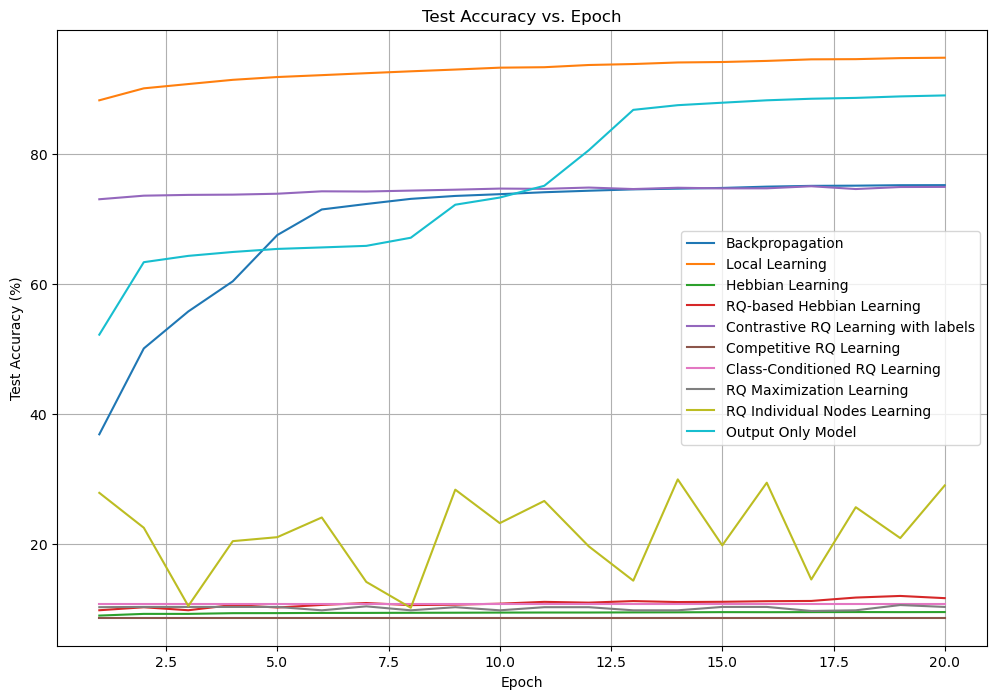

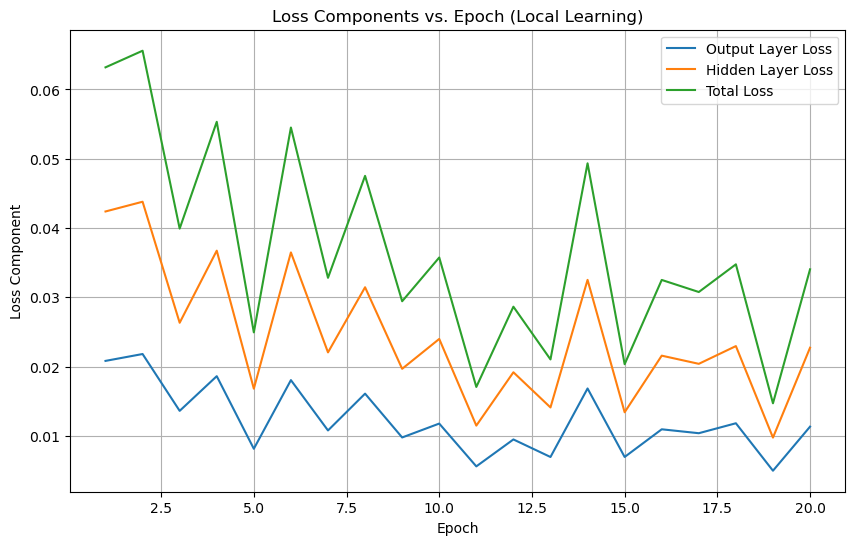

In [30]:
# Main function to train and compare models
def main():
    # Load MNIST dataset
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    epochs = 20  # Reduced epochs for demonstration
    epochs_range = range(1, epochs + 1)

    # Initialize models and optimizers
    models = {}
    optimizers = {}
    train_losses = {}
    train_accuracies = {}
    test_accuracies = {}

    # Backpropagation
    models['backprop'] = LocalLearningNet().to(device)
    optimizers['backprop'] = optim.SGD(models['backprop'].parameters(), lr=0.001)
    train_losses['backprop'] = []
    train_accuracies['backprop'] = []
    test_accuracies['backprop'] = []

    # Local Learning
    models['local'] = LocalLearningNet().to(device)
    optimizers['local'] = optim.SGD(models['local'].parameters(), lr=0.001)
    train_losses['local'] = []
    train_accuracies['local'] = []
    test_accuracies['local'] = []
    loss_components_local = {'output': [], 'hidden': [], 'total': []}

    # Hebbian Learning
    models['hebbian'] = LocalLearningNet().to(device)
    optimizers['hebbian'] = optim.SGD(models['hebbian'].parameters(), lr=0.001)
    train_losses['hebbian'] = []
    train_accuracies['hebbian'] = []
    test_accuracies['hebbian'] = []

    # RQ-based Hebbian Learning
    models['rq_hebbian'] = LocalLearningNet().to(device)
    optimizer_hidden_rq_hebbian = optim.SGD(
        [models['rq_hebbian'].fc1.weight, models['rq_hebbian'].fc1.bias],
        lr=0.001
    )
    optimizer_output_rq_hebbian = optim.SGD(
        [models['rq_hebbian'].fc2.weight, models['rq_hebbian'].fc2.bias],
        lr=0.001
    )
    train_losses['rq_hebbian'] = []
    train_accuracies['rq_hebbian'] = []
    test_accuracies['rq_hebbian'] = []

    # Contrastive RQ Learning
    # Contrastive RQ Learning with Shuffled Labels
    models['contrastive_rq_labels'] = LocalLearningNetWithLabels().to(device)
    optimizer_hidden_contrastive_rq_labels = optim.SGD(
        [models['contrastive_rq_labels'].fc1.weight, models['contrastive_rq_labels'].fc1.bias],
        lr=0.01
    )
    optimizer_output_contrastive_rq_labels = optim.SGD(
        [models['contrastive_rq_labels'].fc2.weight, models['contrastive_rq_labels'].fc2.bias],
        lr=0.01
    )
    train_losses['contrastive_rq_labels'] = []
    train_accuracies['contrastive_rq_labels'] = []
    test_accuracies['contrastive_rq_labels'] = []

    # Competitive RQ Learning
    models['competitive_rq'] = LocalLearningNet().to(device)
    optimizer_hidden_competitive_rq = optim.SGD(
        [models['competitive_rq'].fc1.weight, models['competitive_rq'].fc1.bias],
        lr=0.001
    )
    optimizer_output_competitive_rq = optim.SGD(
        [models['competitive_rq'].fc2.weight, models['competitive_rq'].fc2.bias],
        lr=0.001
    )
    train_losses['competitive_rq'] = []
    train_accuracies['competitive_rq'] = []
    test_accuracies['competitive_rq'] = []

    # Class-Conditioned RQ Learning
    models['class_cond_rq'] = LocalLearningNet().to(device)
    optimizer_hidden = optim.SGD([models['class_cond_rq'].fc1.weight, models['class_cond_rq'].fc1.bias], lr=0.001)
    optimizer_output = optim.SGD([models['class_cond_rq'].fc2.weight, models['class_cond_rq'].fc2.bias], lr=0.001)
    train_losses['class_cond_rq'] = []
    train_accuracies['class_cond_rq'] = []
    test_accuracies['class_cond_rq'] = []
    
    # RQ Maximization Learning
    models['rq_max'] = LocalLearningNet().to(device)
    optimizer_hidden = optim.SGD([models['rq_max'].fc1.weight, models['rq_max'].fc1.bias], lr=0.001)
    optimizer_output = optim.SGD([models['rq_max'].fc2.weight, models['rq_max'].fc2.bias], lr=0.001)
    train_losses['rq_max'] = []
    train_accuracies['rq_max'] = []
    test_accuracies['rq_max'] = []
    
    # RQ Individual Nodes Learning
    models['rq_nodes'] = LocalLearningNet().to(device)
    optimizer_rq_nodes = optim.SGD(models['rq_nodes'].parameters(), lr=0.001)
    train_losses['rq_nodes'] = []
    train_accuracies['rq_nodes'] = []
    test_accuracies['rq_nodes'] = []
    
    # Output Only Model
    models['output_only'] = OutputOnlyNet().to(device)
    optimizers['output_only'] = optim.SGD(models['output_only'].parameters(), lr=0.001)
    train_losses['output_only'] = []
    train_accuracies['output_only'] = []
    test_accuracies['output_only'] = []
    
    # Training loops
    for epoch in epochs_range:
        print(f"Epoch {epoch}:\n")

        # Backpropagation
        train_backprop(models['backprop'], device, train_loader, optimizers['backprop'], epoch, train_losses['backprop'], train_accuracies['backprop'])
        test_accuracy = evaluate(models['backprop'], device, test_loader)
        test_accuracies['backprop'].append(test_accuracy)
        print(f"Backpropagation Test Accuracy: {test_accuracy:.2f}%\n")

        # Local Learning
        train_local_learning(models['local'], device, train_loader, optimizers['local'], epoch, train_losses['local'], train_accuracies['local'])
        test_accuracy = evaluate(models['local'], device, test_loader)
        test_accuracies['local'].append(test_accuracy)
        print(f"Local Learning Test Accuracy: {test_accuracy:.2f}%\n")
        # Compute loss components
        data_iter = iter(train_loader)
        data_sample, target_sample = next(data_iter)
        data_sample = data_sample.view(-1, 784).to(device)
        target_sample = target_sample.to(device)
        loss_output, loss_hidden, total_loss = compute_loss_components(models['local'], data_sample, target_sample)
        loss_components_local['output'].append(loss_output)
        loss_components_local['hidden'].append(loss_hidden)
        loss_components_local['total'].append(total_loss)

        # Hebbian Learning
        train_hebbian_learning(models['hebbian'], device, train_loader, optimizers['hebbian'], epoch, train_losses['hebbian'], train_accuracies['hebbian'])
        test_accuracy = evaluate(models['hebbian'], device, test_loader)
        test_accuracies['hebbian'].append(test_accuracy)
        print(f"Hebbian Learning Test Accuracy: {test_accuracy:.2f}%\n")

        # RQ-based Hebbian Learning
        train_rq_hebbian_learning(
            models['rq_hebbian'],
            device,
            train_loader,
            optimizer_hidden_rq_hebbian,  # Use the correct optimizer variable
            optimizer_output_rq_hebbian,  # Use the correct optimizer variable
            epoch,
            train_losses['rq_hebbian'],
            train_accuracies['rq_hebbian']
        )
        test_accuracy = evaluate(models['rq_hebbian'], device, test_loader)
        test_accuracies['rq_hebbian'].append(test_accuracy)
        print(f"RQ-based Hebbian Learning Test Accuracy: {test_accuracy:.2f}%\n")


        # Contrastive RQ Learning with Shuffled Labels
        train_contrastive_rq_with_labels(
            models['contrastive_rq_labels'],
            device,
            train_loader,
            optimizer_hidden_contrastive_rq_labels,
            optimizer_output_contrastive_rq_labels,
            epoch,
            train_losses['contrastive_rq_labels'],
            train_accuracies['contrastive_rq_labels']
        )
        test_accuracy = evaluate_contrastive_rq_with_labels(
            models['contrastive_rq_labels'], device, test_loader)
        test_accuracies['contrastive_rq_labels'].append(test_accuracy)
        print(f"Contrastive RQ Learning with Shuffled Labels Test Accuracy: {test_accuracy:.2f}%\n")

        # Competitive RQ Learning
        train_competitive_rq_learning(
            models['competitive_rq'],
            device,
            train_loader,
            optimizer_hidden_rq_hebbian,  # Use the correct optimizer variable
            optimizer_output_rq_hebbian,  # Use the correct optimizer variable
            epoch,
            train_losses['competitive_rq'],
            train_accuracies['competitive_rq']
        )
        test_accuracy = evaluate(models['competitive_rq'], device, test_loader)
        test_accuracies['competitive_rq'].append(test_accuracy)
        print(f"Competitive RQ Learning Test Accuracy: {test_accuracy:.2f}%\n")
        


        # Class-Conditioned RQ Learning
        train_class_conditioned_rq_learning(models['class_cond_rq'], device, train_loader, optimizer_hidden, optimizer_output, epoch, train_losses['class_cond_rq'], train_accuracies['class_cond_rq'])
        test_accuracy = evaluate(models['class_cond_rq'], device, test_loader)
        test_accuracies['class_cond_rq'].append(test_accuracy)
        print(f"Class-Conditioned RQ Learning Test Accuracy: {test_accuracy:.2f}%\n")
    
        # RQ Maximization Learning
        train_rq_maximization(models['rq_max'], device, train_loader, optimizer_hidden, optimizer_output, epoch, train_losses['rq_max'], train_accuracies['rq_max'])
        test_accuracy = evaluate(models['rq_max'], device, test_loader)
        test_accuracies['rq_max'].append(test_accuracy)
        print(f"RQ Maximization Learning Test Accuracy: {test_accuracy:.2f}%\n")   
        
        # RQ Individual Nodes Learning
        train_rq_individual_nodes(models['rq_nodes'], device, train_loader, optimizer_rq_nodes, epoch, train_losses['rq_nodes'], train_accuracies['rq_nodes'], alpha=0.01)
        test_accuracy = evaluate(models['rq_nodes'], device, test_loader)
        test_accuracies['rq_nodes'].append(test_accuracy)
        print(f"RQ Individual Nodes Learning Test Accuracy: {test_accuracy:.2f}%\n")
        
        # Output Only Model
        train_output_only(models['output_only'], device, train_loader, optimizers['output_only'], epoch, train_losses['output_only'], train_accuracies['output_only'])
        test_accuracy = evaluate_output_only(models['output_only'], device, test_loader)
        test_accuracies['output_only'].append(test_accuracy)
        print(f"Output Only Model Test Accuracy: {test_accuracy:.2f}%\n")


    # Plotting results
    plt.figure(figsize=(12, 8))
    plt.plot(epochs_range, test_accuracies['backprop'], label='Backpropagation')
    plt.plot(epochs_range, test_accuracies['local'], label='Local Learning')
    plt.plot(epochs_range, test_accuracies['hebbian'], label='Hebbian Learning')
    plt.plot(epochs_range, test_accuracies['rq_hebbian'], label='RQ-based Hebbian Learning')
    plt.plot(epochs_range, test_accuracies['contrastive_rq_labels'], label='Contrastive RQ Learning with labels')
    plt.plot(epochs_range, test_accuracies['competitive_rq'], label='Competitive RQ Learning')
    plt.plot(epochs_range, test_accuracies['class_cond_rq'], label='Class-Conditioned RQ Learning')
    plt.plot(epochs_range, test_accuracies['rq_max'], label='RQ Maximization Learning')
    plt.plot(epochs_range, test_accuracies['rq_nodes'], label='RQ Individual Nodes Learning')
    plt.plot(epochs_range, test_accuracies['output_only'], label='Output Only Model')    
    plt.xlabel('Epoch')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Test Accuracy vs. Epoch')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot loss components for local learning
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, loss_components_local['output'], label='Output Layer Loss')
    plt.plot(epochs_range, loss_components_local['hidden'], label='Hidden Layer Loss')
    plt.plot(epochs_range, loss_components_local['total'], label='Total Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Component')
    plt.title('Loss Components vs. Epoch (Local Learning)')
    plt.legend()
    plt.grid(True)
    plt.show()
        
if __name__ == '__main__':
    main()